# 🌐 Point Cloud Volume Estimation: A Deep Learning Study Notebook

---

## 📋 Notebook Overview

This is a **comprehensive educational notebook** for studying deep learning on 3D point cloud data.  
We implement **5 state-of-the-art models** for a **regression task**: predicting the volume of wood powder piles from `.las` LiDAR point cloud files.

### Models Covered:
| Model | Key Idea | Year |
|-------|----------|------|
| **PointNet** | Shared MLP + Global Max Pool (permutation invariant) | 2017 |
| **PointNet++** | Hierarchical Set Abstraction (local + global) | 2017 |
| **PointNeXt** | Improved PointNet++ with InvResidual blocks | 2022 |
| **PointMAE** | Masked Autoencoder pre-training for point clouds | 2022 |
| **DGCNN** | Dynamic Graph CNN with EdgeConv | 2019 |

### Task:
- **Input**: `.las` point cloud files (x, y, z coordinates)
- **Output**: A single continuous value — **Volume** (regression)
- **Metric**: MAE, RMSE, MSE, R², MAPE

---

> 💡 **How to use this notebook**: Set `MODEL_NAME = "DGCNN"` (or any other model) at the top of Section 2, then **Run All Cells**. The entire pipeline — preprocessing → training → evaluation → visualization — runs automatically.


---
## 📦 Section 1: Imports

We import all required libraries upfront. Each library serves a specific role:
- `laspy`: Reads `.las` LiDAR point cloud files
- `open3d`: 3D point cloud processing and (optional) visualization
- `torch` + modules: Deep learning framework
- `sklearn`: Data splitting and metrics
- `matplotlib` / `seaborn`: Visualizations


In [21]:
# ─────────────────────────────────────────────────────────
# Standard Library
# ─────────────────────────────────────────────────────────
import os
import time
import csv
import json
import warnings
import random
from pathlib import Path

# ─────────────────────────────────────────────────────────
# Numerical & Data
# ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────
# Point Cloud I/O
# ─────────────────────────────────────────────────────────
import laspy
import open3d as o3d

# ─────────────────────────────────────────────────────────
# Machine Learning
# ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ─────────────────────────────────────────────────────────
# Deep Learning (PyTorch)
# ─────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import GradScaler, autocast

# ─────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
print("✅ All imports successful!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU             : {torch.cuda.get_device_name(0)}")


✅ All imports successful!
   PyTorch version : 2.11.0+cu130
   CUDA available  : True
   GPU             : NVIDIA GeForce RTX 3060


---
## ⚙️ Section 2: Configuration

> **🔑 KEY SETTING — Change only this one variable to switch models!**

Set `MODEL_NAME` to any of:  
`"PointNet"` | `"PointNetPP"` | `"PointNeXt"` | `"PointMAE"` | `"DGCNN"`

All hyperparameters, paths, and output directories are derived from this single variable.


In [22]:
# ════════════════════════════════════════════════════════
# 🔑 CHANGE ONLY THIS LINE TO SWITCH MODELS
# ════════════════════════════════════════════════════════
MODEL_NAME = "PointNetPP"   # Options: "PointNet", "PointNetPP", "PointNeXt", "PointMAE", "DGCNN"

# ─────────────────────────────────────────────────────────
# Reproducibility
# ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ─────────────────────────────────────────────────────────
# Device
# ─────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")

# ─────────────────────────────────────────────────────────
# Training Hyperparameters
# ─────────────────────────────────────────────────────────
NUM_POINTS   = 2048      # Points sampled per cloud (FPS)
BATCH_SIZE   = 16        # Samples per batch
NUM_EPOCHS   = 50        # Total training epochs
LR           = 0.001     # Learning rate
WEIGHT_DECAY = 1e-4      # L2 regularization
T_0          = 10        # Cosine LR restart period
GRAD_CLIP    = 1.0       # Max gradient norm
USE_AMP      = torch.cuda.is_available()  # Mixed precision (GPU only)

# ─────────────────────────────────────────────────────────
# Paths
# ─────────────────────────────────────────────────────────
DATA_DIR     = Path("sample_data")
RESULTS_DIR  = Path("results") / MODEL_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PATH    = RESULTS_DIR / f"best_{MODEL_NAME.lower()}.pth"
CSV_LOG_PATH = RESULTS_DIR / f"{MODEL_NAME}_training_log.csv"
COMPARISON_CSV = Path("results") / "model_comparison.csv"
COMPARISON_CSV.parent.mkdir(parents=True, exist_ok=True)

print(f"\n📁 Configuration Summary:")
print(f"   Model       : {MODEL_NAME}")
print(f"   Num Points  : {NUM_POINTS}")
print(f"   Batch Size  : {BATCH_SIZE}")
print(f"   Epochs      : {NUM_EPOCHS}")
print(f"   Results Dir : {RESULTS_DIR}")


🖥️  Device: cuda

📁 Configuration Summary:
   Model       : PointNetPP
   Num Points  : 2048
   Batch Size  : 16
   Epochs      : 50
   Results Dir : results/PointNetPP


---
## 🗂️ Section 3: Dataset Paths & Exploration

Before training, we explore our dataset to understand:
1. How many `.las` files we have
2. The distribution of point counts per cloud
3. The distribution of target volumes

**Why this matters**: Point clouds can have very different sizes. We need to normalize/sample them to a fixed count for batching in neural networks.


In [23]:
# ─────────────────────────────────────────────────────────
# Scan the data directory for .las files
# ─────────────────────────────────────────────────────────
csv_path = DATA_DIR / "volume.csv"

if not csv_path.exists():
    raise FileNotFoundError(
        f"❌ Could not find {csv_path}\n"
        f"   Please ensure 'sample_data/volume.csv' exists with columns: [filename, volume]"
    )

df = pd.read_csv(csv_path)
print(f"📊 Dataset Summary:")
print(f"   Total samples : {len(df)}")
print(f"   Columns       : {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nVolume statistics:")
print(df.iloc[:, 1].describe())


📊 Dataset Summary:
   Total samples : 200
   Columns       : ['filename', 'volume_m3']

First 5 rows:
          filename  volume_m3
0  sample_0000.las   7.531572
1  sample_0001.las   0.591013
2  sample_0002.las   7.420727
3  sample_0003.las   1.109444
4  sample_0004.las   0.210711

Volume statistics:
count    200.000000
mean       2.530937
std        2.185844
min        0.117557
25%        0.827462
50%        1.827505
75%        3.820825
max       11.059159
Name: volume_m3, dtype: float64



📏 Point count statistics:
count       200.0
mean     242175.9
std      186042.0
min       28556.0
25%      111672.8
50%      177163.0
75%      331632.2
max      965407.0
Name: num_points, dtype: float64


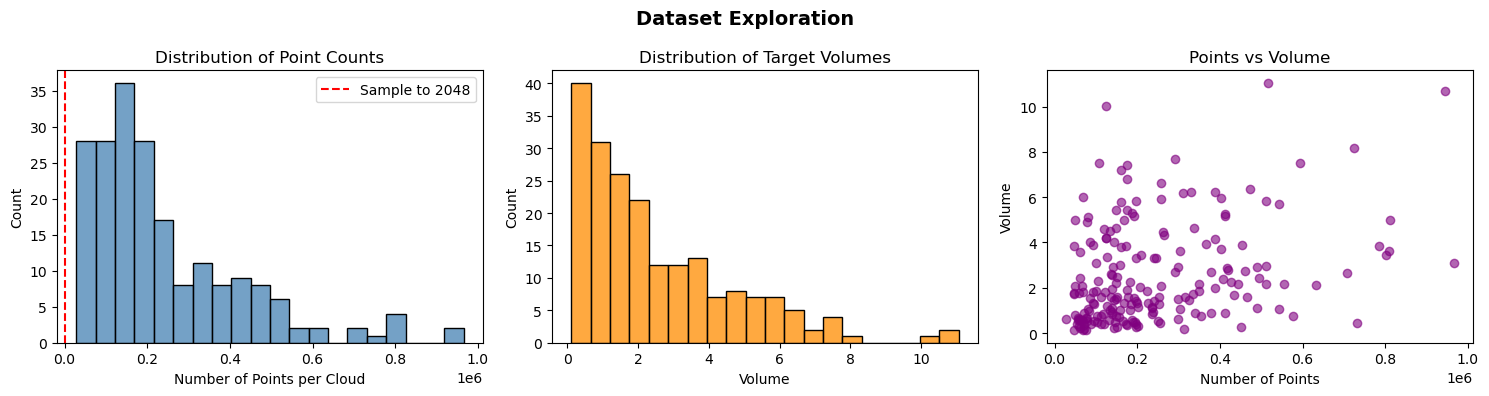

✅ Exploration plot saved.


In [24]:
# ─────────────────────────────────────────────────────────
# Count actual points per .las file (explore point density)
# ─────────────────────────────────────────────────────────
points_info = []
missing_files = []

for idx, row in df.iterrows():
    las_path = DATA_DIR / row.iloc[0]
    if las_path.exists():
        try:
            las = laspy.read(str(las_path))
            n_pts = len(las.x)
            points_info.append({
                "filename": row.iloc[0],
                "num_points": n_pts,
                "volume": row.iloc[1]
            })
        except Exception as e:
            print(f"⚠️  Error reading {las_path}: {e}")
    else:
        missing_files.append(str(las_path))

if missing_files:
    print(f"⚠️  {len(missing_files)} missing files: {missing_files[:3]}{'...' if len(missing_files)>3 else ''}")

if points_info:
    pts_df = pd.DataFrame(points_info)
    print(f"\n📏 Point count statistics:")
    print(pts_df["num_points"].describe().round(1))
    
    # ─── Visualization ───────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Dataset Exploration", fontsize=14, fontweight='bold')
    
    sns.histplot(pts_df["num_points"], bins=20, ax=axes[0], color='steelblue')
    axes[0].set_title("Distribution of Point Counts")
    axes[0].set_xlabel("Number of Points per Cloud")
    axes[0].axvline(NUM_POINTS, color='red', linestyle='--', label=f'Sample to {NUM_POINTS}')
    axes[0].legend()
    
    sns.histplot(pts_df["volume"], bins=20, ax=axes[1], color='darkorange')
    axes[1].set_title("Distribution of Target Volumes")
    axes[1].set_xlabel("Volume")
    
    axes[2].scatter(pts_df["num_points"], pts_df["volume"], alpha=0.6, color='purple')
    axes[2].set_title("Points vs Volume")
    axes[2].set_xlabel("Number of Points")
    axes[2].set_ylabel("Volume")
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "dataset_exploration.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Exploration plot saved.")
else:
    print("⚠️  No readable .las files found. Proceeding with CSV-only mode.")


---
## 🔬 Section 4: Data Preprocessing — Key Concepts

### 4.1 Why Do We Need Preprocessing?

Raw `.las` files have **varying numbers of points** (e.g., 5,000 to 500,000). Neural networks require **fixed-size inputs**. We solve this with:

1. **Farthest Point Sampling (FPS)** — if more points than needed, sample the most spread-out `N` points
2. **Random Oversampling** — if fewer points than needed, sample with replacement
3. **Zero-centering** — subtract the centroid so the cloud is centered at the origin

### 4.2 Farthest Point Sampling (FPS)

FPS is a greedy algorithm that selects points maximally spread across the cloud:

```
Algorithm:
1. Randomly pick a starting point p₀
2. For each new point pᵢ:
   - Compute distance from all points to the nearest already-selected point
   - Pick the point with the LARGEST minimum distance
3. Repeat until N points selected
```

**Why FPS over random sampling?**  
FPS preserves the **global shape** better — no large empty regions, no cluster bias.

### 4.3 Data Augmentation (Training Only)

To improve generalization, we randomly augment during training:
- **Z-axis rotation** (random θ ∈ [0, 2π]) — realistic since aerial/scanner views rotate
- **Gaussian jitter** (σ=0.01) — simulates sensor noise


---
## 🗃️ Section 5: Dataset Class

The `WoodPowderDataset` class wraps our data for PyTorch's `DataLoader`.

**Output tensor shape**: `(3, N)` where `3 = (x,y,z)` channels and `N = NUM_POINTS`.  
This channel-first format is required by Conv1d layers in all our models.


In [25]:
class WoodPowderDataset(Dataset):
    """
    PyTorch Dataset for LiDAR point cloud volume regression.
    
    Args:
        csv_file  : Path to CSV with columns [filename, volume]
        data_dir  : Directory containing .las files
        num_points: Number of points to sample per cloud (default: 2048)
        train     : If True, apply data augmentation
        
    Returns (per item):
        points_tensor : FloatTensor of shape (3, num_points)  ← channel-first
        volume_tensor : FloatTensor scalar (the target volume)
    """
    
    def __init__(self, csv_file, data_dir, num_points=2048, train=True):
        self.data_frame = pd.read_csv(csv_file)
        self.data_dir   = Path(data_dir)
        self.num_points = num_points
        self.train      = train
    
    def __len__(self):
        return len(self.data_frame)
    
    # ── Farthest Point Sampling ──────────────────────────
    def farthest_point_sample(self, xyz: np.ndarray, npoint: int) -> np.ndarray:
        """
        Select `npoint` points from xyz using FPS.
        
        Tensor flow:
          Input : xyz  shape (N, 3)
          Output: sampled_xyz  shape (npoint, 3)
        """
        N = xyz.shape[0]
        centroids = np.zeros(npoint, dtype=np.int32)
        distance  = np.ones(N) * 1e10      # ∞ distance initially
        farthest  = np.random.randint(0, N) # random start
        
        for i in range(npoint):
            centroids[i] = farthest
            centroid      = xyz[farthest, :]
            # Distance from all points to current centroid
            dist          = np.sum((xyz - centroid) ** 2, axis=-1)
            # Keep the MINIMUM distance to any selected point
            mask          = dist < distance
            distance[mask]= dist[mask]
            # Next point = farthest from the selected set
            farthest      = np.argmax(distance)
        
        return xyz[centroids]   # shape: (npoint, 3)
    
    # ── Data Augmentation ────────────────────────────────
    def augment_point_cloud(self, points: np.ndarray) -> np.ndarray:
        """
        Apply random Z-axis rotation + Gaussian jitter.
        
        Only applied during training to avoid test set leakage.
        
        Tensor flow:
          Input/Output : points  shape (N, 3)
        """
        # Random rotation around Z-axis (yaw)
        theta      = np.random.uniform(0, 2 * np.pi)
        rot_matrix = np.array([
            [np.cos(theta), -np.sin(theta), 0],
            [np.sin(theta),  np.cos(theta), 0],
            [0,              0,             1]
        ])
        points = np.dot(points, rot_matrix)          # (N,3) @ (3,3) → (N,3)
        
        # Gaussian noise (simulates sensor noise)
        points += np.random.normal(0, 0.01, size=points.shape)
        
        return points
    
    def __getitem__(self, idx: int):
        """
        Load one sample. Called by DataLoader for each item in a batch.
        
        Tensor dimensions at each step:
          raw points      : (N_raw, 3)   ← variable N_raw per file
          after FPS/pad   : (2048, 3)    ← fixed size
          after centering : (2048, 3)    ← zero-mean
          after transpose : (3, 2048)    ← channel-first for Conv1d
        """
        # 1. Read filename and ground-truth volume from CSV
        las_path  = self.data_dir / self.data_frame.iloc[idx, 0]
        gt_volume = float(self.data_frame.iloc[idx, 1])
        
        # 2. Load .las file  →  shape: (N_raw, 3)
        las    = laspy.read(str(las_path))
        points = np.vstack((las.x, las.y, las.z)).T.astype(np.float32)
        # Tensor shape: (N_raw, 3)
        
        # 3. Sample to fixed size
        if len(points) > self.num_points:
            points = self.farthest_point_sample(points, self.num_points)
            # Tensor shape: (2048, 3)
        else:
            # Random oversample (with replacement) if too few points
            choices = np.random.choice(len(points), self.num_points, replace=True)
            points  = points[choices]
            # Tensor shape: (2048, 3)
        
        # 4. Zero-center (subtract centroid)
        centroid = np.mean(points, axis=0)  # shape: (3,)
        points   = points - centroid         # shape: (2048, 3)
        
        # 5. Augment (training only)
        if self.train:
            points = self.augment_point_cloud(points)
            # Tensor shape: (2048, 3)
        
        # 6. Convert to PyTorch tensors
        #    Transpose: (2048, 3) → (3, 2048)  ← required by Conv1d
        points_tensor = torch.from_numpy(points).T.float()   # (3, 2048)
        volume_tensor = torch.tensor(gt_volume, dtype=torch.float32)  # scalar
        
        return points_tensor, volume_tensor


print("✅ WoodPowderDataset class defined.")
print("   Output shape: points=(3, 2048), volume=(scalar,)")


✅ WoodPowderDataset class defined.
   Output shape: points=(3, 2048), volume=(scalar,)


---
## 🔀 Section 6: Train / Validation / Test Split & DataLoaders

We use an **80/10/10 split**:
- **Train** (80%): Model sees these during training
- **Validation** (10%): Monitor generalization, save best checkpoint
- **Test** (10%): Final held-out evaluation — never touched during training

**DataLoader settings:**
- `num_workers`: Parallel data loading (CPU threads)
- `pin_memory`: Keeps data in pinned memory for faster GPU transfer
- `drop_last`: Drops incomplete final batch (avoids BatchNorm issues with batch_size=1)


In [26]:
# ─────────────────────────────────────────────────────────
# Split the dataset
# ─────────────────────────────────────────────────────────
df = pd.read_csv(csv_path)

# First split off 20% for val+test
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=SEED)
# Split the 20% equally into val and test (10% each)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=SEED)

# Save split CSVs
train_csv = DATA_DIR / "train_volume.csv"
val_csv   = DATA_DIR / "val_volume.csv"
test_csv  = DATA_DIR / "test_volume.csv"
train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv,   index=False)
test_df.to_csv(test_csv,  index=False)

print(f"📊 Dataset Split:")
print(f"   Total   : {len(df):>4} samples (100%)")
print(f"   Train   : {len(train_df):>4} samples ( 80%)")
print(f"   Val     : {len(val_df):>4} samples ( 10%)")
print(f"   Test    : {len(test_df):>4} samples ( 10%)")

# ─────────────────────────────────────────────────────────
# Instantiate Datasets
# ─────────────────────────────────────────────────────────
train_dataset = WoodPowderDataset(train_csv, DATA_DIR, num_points=NUM_POINTS, train=True)
val_dataset   = WoodPowderDataset(val_csv,   DATA_DIR, num_points=NUM_POINTS, train=False)
test_dataset  = WoodPowderDataset(test_csv,  DATA_DIR, num_points=NUM_POINTS, train=False)

# ─────────────────────────────────────────────────────────
# DataLoaders
# ─────────────────────────────────────────────────────────
WORKERS = min(8, os.cpu_count() or 4)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=WORKERS, pin_memory=True, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=WORKERS, pin_memory=True, drop_last=False)

# ─────────────────────────────────────────────────────────
# Verify shapes with one batch
# ─────────────────────────────────────────────────────────
sample_pts, sample_vol = next(iter(train_loader))
print(f"\n✅ DataLoaders Ready!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")
print(f"\n📐 Sample batch shapes:")
print(f"   Points  : {sample_pts.shape}   ← (batch, 3, N_points)")
print(f"   Volumes : {sample_vol.shape}  ← (batch,)")


📊 Dataset Split:
   Total   :  200 samples (100%)
   Train   :  160 samples ( 80%)
   Val     :   20 samples ( 10%)
   Test    :   20 samples ( 10%)

✅ DataLoaders Ready!
   Train batches : 10
   Val batches   : 2
   Test batches  : 2

📐 Sample batch shapes:
   Points  : torch.Size([16, 3, 2048])   ← (batch, 3, N_points)
   Volumes : torch.Size([16])  ← (batch,)


---
## 🔧 Section 7: Common Utilities & Metrics

### Metrics Explained

| Metric | Formula | Intuition |
|--------|---------|-----------|
| **MAE** | mean(|pred - gt|) | Average absolute error (same units as target) |
| **RMSE** | √mean((pred-gt)²) | Penalizes large errors more than MAE |
| **MSE** | mean((pred-gt)²) | Squared error (used as training loss) |
| **R²** | 1 - SS_res/SS_tot | % variance explained (1.0 = perfect) |
| **MAPE** | mean(|pred-gt|/|gt|)×100 | Percentage error (scale-invariant) |

> ⚠️ **MAPE caution**: undefined when `gt ≈ 0`. We add a small epsilon `ε=1e-8`.


✅ Utilities, metrics, and logger functions defined.


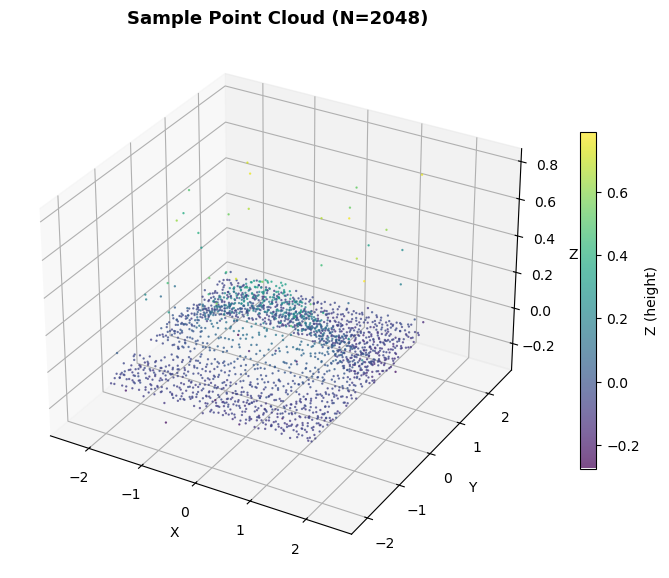

In [27]:
# ─────────────────────────────────────────────────────────
# Metrics
# ─────────────────────────────────────────────────────────
def compute_metrics(preds: np.ndarray, targets: np.ndarray) -> dict:
    """
    Compute all regression metrics.
    
    Args:
        preds   : numpy array of predictions
        targets : numpy array of ground truth values
    Returns:
        dict with MAE, RMSE, MSE, R2, MAPE
    """
    eps  = 1e-8
    mae  = mean_absolute_error(targets, preds)
    mse  = mean_squared_error(targets, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(targets, preds)
    mape = np.mean(np.abs(preds - targets) / (np.abs(targets) + eps)) * 100
    
    return {"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2, "MAPE": mape}


def compute_metrics_torch(preds: torch.Tensor, targets: torch.Tensor) -> dict:
    """Torch version of metrics (used inside training loop)."""
    eps    = 1e-8
    mae    = torch.abs(preds - targets).mean().item()
    mse    = F.mse_loss(preds, targets).item()
    rmse   = np.sqrt(mse)
    mape   = (torch.abs(preds - targets) / (torch.abs(targets) + eps)).mean().item() * 100
    return {"MAE": mae, "RMSE": rmse, "MSE": mse, "MAPE": mape}


# ─────────────────────────────────────────────────────────
# CSV Logger
# ─────────────────────────────────────────────────────────
def init_csv_logger(path: Path) -> None:
    """Initialize CSV log file with header row."""
    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            "Epoch", "Train_Loss", "Val_Loss",
            "Train_MAE", "Val_MAE",
            "Train_RMSE", "Val_RMSE",
            "Train_MSE", "Val_MSE",
            "Train_MAPE", "Val_MAPE",
            "LR", "Time_s"
        ])

def log_epoch_csv(path: Path, row: list) -> None:
    """Append one epoch row to the CSV log."""
    with open(path, 'a', newline='') as f:
        csv.writer(f).writerow(row)


# ─────────────────────────────────────────────────────────
# Point Cloud Visualization (matplotlib — no GUI needed)
# ─────────────────────────────────────────────────────────
def visualize_point_cloud(points: np.ndarray, title: str = "Point Cloud",
                           save_path: Path = None) -> None:
    """
    Render a 3D scatter plot of a point cloud.
    
    Args:
        points    : numpy array shape (N, 3) or (3, N)
        title     : plot title
        save_path : if given, saves the figure
    """
    if points.shape[0] == 3:
        points = points.T          # (3,N) → (N,3)
    
    fig = plt.figure(figsize=(7, 6))
    ax  = fig.add_subplot(111, projection='3d')
    sc  = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                     c=points[:, 2], cmap='viridis', s=0.5, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='Z (height)', shrink=0.6)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


print("✅ Utilities, metrics, and logger functions defined.")

# ─── Visualize one sample point cloud ────────────────────
sample_pts_np = sample_pts[0].numpy()   # shape: (3, 2048)
visualize_point_cloud(sample_pts_np,
                      title=f"Sample Point Cloud (N={NUM_POINTS})",
                      save_path=RESULTS_DIR / "sample_point_cloud.png")


---
## 🏗️ Section 8: Model Architectures

Below we implement all 5 models. For each we:
1. Explain the **key concept** and paper reference
2. Show the **architecture diagram** (as text)
3. Annotate every forward pass with **tensor shapes**

---

### 8.1 PointNet

**Paper**: *PointNet: Deep Learning on Point Sets for 3D Classification and Segmentation*  
Qi et al., CVPR 2017. [arXiv:1612.00593](https://arxiv.org/abs/1612.00593)

#### Key Insight: Permutation Invariance via Symmetric Function
Point clouds are **unordered sets** — the same shape can be described with points in any order.  
PointNet handles this by:
1. Applying a **shared MLP** independently to each point (order doesn't matter)
2. Aggregating with **global max pooling** — a symmetric function that produces the same output regardless of point order

#### Architecture (simplified, without T-Net):
```
Input (B, 3, N)
    ↓
Conv1d(3→64) + BN + ReLU         (B, 64, N)
Conv1d(64→128) + BN + ReLU       (B, 128, N)
Conv1d(128→1024) + BN + ReLU     (B, 1024, N)
    ↓
Global Max Pool                   (B, 1024)   ← symmetric function
    ↓
FC(1024→512) + BN + ReLU + Drop  (B, 512)
FC(512→256) + BN + ReLU + Drop   (B, 256)
FC(256→1)                        (B, 1)      ← volume prediction
```

#### T-Net (Spatial Transformer Network):
The original PointNet also includes a T-Net that predicts a 3×3 transformation matrix to align input points. We include it here for completeness.


In [28]:
# ══════════════════════════════════════════════════════════
# MODEL 1: PointNet
# Paper: Qi et al., CVPR 2017 (arXiv:1612.00593)
# ══════════════════════════════════════════════════════════

class TNet(nn.Module):
    """
    Spatial Transformer Network (T-Net).
    
    Predicts a k×k transformation matrix to canonicalize input
    point coordinates or features — making PointNet invariant
    to geometric transformations.
    
    Input : (B, k, N)  — k=3 for input, k=64 for feature transform
    Output: (B, k, k)  — transformation matrix
    """
    def __init__(self, k=3):
        super().__init__()
        self.k = k
        self.conv1 = nn.Conv1d(k, 64, 1);   self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, 1); self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 1024, 1); self.bn3 = nn.BatchNorm1d(1024)
        self.fc1   = nn.Linear(1024, 512); self.bn4 = nn.BatchNorm1d(512)
        self.fc2   = nn.Linear(512, 256);  self.bn5 = nn.BatchNorm1d(256)
        self.fc3   = nn.Linear(256, k * k)
        # Initialize as identity transform
        self.fc3.weight.data.zero_()
        self.fc3.bias.data.copy_(torch.eye(k).view(-1))
    
    def forward(self, x):
        # x: (B, k, N)
        x = F.relu(self.bn1(self.conv1(x)))   # (B, 64, N)
        x = F.relu(self.bn2(self.conv2(x)))   # (B, 128, N)
        x = F.relu(self.bn3(self.conv3(x)))   # (B, 1024, N)
        x = torch.max(x, 2)[0]               # (B, 1024)
        x = F.relu(self.bn4(self.fc1(x)))    # (B, 512)
        x = F.relu(self.bn5(self.fc2(x)))    # (B, 256)
        x = self.fc3(x)                      # (B, k*k)
        return x.view(-1, self.k, self.k)    # (B, k, k)


class PointNetRegressor(nn.Module):
    """
    PointNet for volume regression.
    
    Architecture:
        Input (B, 3, N)
          → T-Net input transform → (B, 3, N)
          → MLP(64,64) → (B, 64, N)
          → T-Net feature transform → (B, 64, N)
          → MLP(64,128,1024) → (B, 1024, N)
          → Global Max Pool → (B, 1024)
          → FC regression head → (B, 1)
    """
    def __init__(self, num_points=2048):
        super().__init__()
        
        # Input T-Net (3×3 transform)
        self.tnet_input = TNet(k=3)
        
        # Shared MLP — first block
        self.conv1 = nn.Conv1d(3, 64, 1);   self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, 1);  self.bn2 = nn.BatchNorm1d(64)
        
        # Feature T-Net (64×64 transform)
        self.tnet_feat = TNet(k=64)
        
        # Shared MLP — second block
        self.conv3 = nn.Conv1d(64, 64, 1);   self.bn3 = nn.BatchNorm1d(64)
        self.conv4 = nn.Conv1d(64, 128, 1);  self.bn4 = nn.BatchNorm1d(128)
        self.conv5 = nn.Conv1d(128, 1024, 1); self.bn5 = nn.BatchNorm1d(1024)
        
        # Regression head
        self.fc1 = nn.Linear(1024, 512); self.bn6 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256);  self.bn7 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 1)
        self.drop = nn.Dropout(p=0.3)
    
    def forward(self, x):
        B, _, N = x.shape
        # ── Input transform ──────────────────────────────
        # x: (B, 3, N)
        T_in = self.tnet_input(x)          # (B, 3, 3)
        x    = torch.bmm(T_in, x)          # (B, 3, 3) @ (B, 3, N) → (B, 3, N)
        
        # ── MLP block 1 ──────────────────────────────────
        x = F.relu(self.bn1(self.conv1(x)))   # (B, 64, N)
        x = F.relu(self.bn2(self.conv2(x)))   # (B, 64, N)
        
        # ── Feature transform ─────────────────────────────
        T_feat = self.tnet_feat(x)             # (B, 64, 64)
        x      = torch.bmm(T_feat, x)          # (B, 64, N)
        
        # ── MLP block 2 ──────────────────────────────────
        x = F.relu(self.bn3(self.conv3(x)))    # (B, 64, N)
        x = F.relu(self.bn4(self.conv4(x)))    # (B, 128, N)
        x = F.relu(self.bn5(self.conv5(x)))    # (B, 1024, N)
        
        # ── Global Max Pooling ────────────────────────────
        x = torch.max(x, 2)[0]                # (B, 1024)
        
        # ── Regression Head ───────────────────────────────
        x = F.relu(self.bn6(self.fc1(x)))      # (B, 512)
        x = self.drop(x)
        x = F.relu(self.bn7(self.fc2(x)))      # (B, 256)
        x = self.drop(x)
        x = self.fc3(x)                        # (B, 1)
        
        return x.squeeze(-1)                   # (B,)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Quick test
_m = PointNetRegressor(NUM_POINTS)
_x = torch.randn(2, 3, NUM_POINTS)
_y = _m(_x)
print(f"✅ PointNet")
print(f"   Input  : {_x.shape}")
print(f"   Output : {_y.shape}")
print(f"   Params : {_m.count_params():,}")
del _m, _x, _y


✅ PointNet
   Input  : torch.Size([2, 3, 2048])
   Output : torch.Size([2])
   Params : 3,470,026


---
### 8.2 PointNet++

**Paper**: *PointNet++: Deep Hierarchical Feature Learning on Point Sets in a Metric Space*  
Qi et al., NeurIPS 2017. [arXiv:1706.02413](https://arxiv.org/abs/1706.02413)

#### Key Insight: Hierarchical Local-Global Feature Learning

PointNet treats all points **globally**. PointNet++ adds a **hierarchical structure** inspired by CNNs:

```
Set Abstraction (SA) Block:
  1. Farthest Point Sampling  → select M centroid points
  2. Ball Query               → for each centroid, find K neighbors within radius r
  3. PointNet (local)         → extract features from each local neighborhood
  
Stack multiple SA blocks with increasing radius, decreasing point count:
  Level 1: 512 points, r=0.2  → local fine features
  Level 2: 128 points, r=0.4  → medium features
  Level 3:  32 points, r=0.8  → coarse global features
```

This creates a **local-to-global** hierarchy — similar to how CNNs go from edges → textures → objects.

#### Architecture:
```
Input (B, N, 3)
    ↓
SA(512, r=0.2, [64,64,128])    (B, 512, 128)
    ↓
SA(128, r=0.4, [128,128,256])  (B, 128, 256)
    ↓
SA( 32, r=0.8, [256,512,1024]) (B,  32, 1024)
    ↓
Global Pooling                  (B, 1024)
    ↓
FC(512) → FC(256) → FC(1)      (B, 1)
```


In [29]:
# ══════════════════════════════════════════════════════════
# MODEL 2: PointNet++
# Paper: Qi et al., NeurIPS 2017 (arXiv:1706.02413)
# ══════════════════════════════════════════════════════════

def fps_torch(xyz: torch.Tensor, npoint: int) -> torch.Tensor:
    """
    Farthest Point Sampling (GPU-compatible).
    
    Args:
        xyz    : (B, N, 3) point cloud positions
        npoint : number of points to sample
    Returns:
        centroids: (B, npoint) indices of sampled points
    """
    device    = xyz.device
    B, N, _   = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=device)
    distance  = torch.ones(B, N, device=device) * 1e10
    farthest  = torch.randint(0, N, (B,), dtype=torch.long, device=device)
    
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[torch.arange(B, device=device), farthest, :].unsqueeze(1)  # (B,1,3)
        dist     = torch.sum((xyz - centroid) ** 2, dim=-1)   # (B, N)
        mask     = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.argmax(distance, dim=-1)              # (B,)
    
    return centroids   # (B, npoint)


def ball_query(radius: float, nsample: int, xyz: torch.Tensor,
               new_xyz: torch.Tensor) -> torch.Tensor:
    """
    Ball Query: find up to `nsample` neighbors within `radius` for each centroid.
    
    Args:
        radius  : search radius r
        nsample : max neighbors K
        xyz     : (B, N, 3) all points
        new_xyz : (B, S, 3) centroid points
    Returns:
        idx: (B, S, K) neighbor indices (padded by repeating first neighbor)
    """
    device    = xyz.device
    B, N, _   = xyz.shape
    _, S, _   = new_xyz.shape
    
    # Pairwise distances: (B, S, N)
    dists = torch.cdist(new_xyz, xyz)   # (B, S, N)
    
    # Neighbors within radius
    idx = dists.argsort(dim=-1)[:, :, :nsample]           # (B, S, K) nearest
    
    # Mask out-of-radius neighbors → replace with first neighbor (padding)
    valid_mask = dists.gather(2, idx) <= radius            # (B, S, K) bool
    first_nb   = idx[:, :, 0:1].expand_as(idx)            # (B, S, K)
    idx        = torch.where(valid_mask, idx, first_nb)   # (B, S, K)
    
    return idx   # (B, S, K)


def sample_and_group(npoint, radius, nsample, xyz, points):
    """
    Sample centroids + group neighbors.
    
    Args:
        npoint  : number of centroids to sample (S)
        radius  : ball query radius
        nsample : max neighbors per centroid (K)
        xyz     : (B, N, 3) coordinates
        points  : (B, N, C) features (or None)
    Returns:
        new_xyz    : (B, S, 3)      centroid positions
        new_points : (B, S, K, C+3) grouped features with relative coords
    """
    B, N, _ = xyz.shape
    
    # 1. FPS → centroids
    fps_idx = fps_torch(xyz, npoint)                       # (B, S)
    new_xyz = xyz[torch.arange(B).unsqueeze(1), fps_idx]  # (B, S, 3)
    
    # 2. Ball Query → neighbor indices
    idx = ball_query(radius, nsample, xyz, new_xyz)        # (B, S, K)
    
    # 3. Gather neighbor points
    idx_exp  = idx.unsqueeze(-1).expand(-1, -1, -1, 3)    # (B, S, K, 3)
    xyz_exp  = xyz.unsqueeze(1).expand(-1, npoint, -1, -1)# (B, S, N, 3)
    grouped  = xyz_exp.gather(2, idx_exp)                  # (B, S, K, 3)
    
    # 4. Subtract centroid → relative coords
    grouped -= new_xyz.unsqueeze(2)                        # (B, S, K, 3)
    
    # 5. Concatenate features if available
    if points is not None:
        C        = points.shape[-1]
        idx_fp   = idx.unsqueeze(-1).expand(-1, -1, -1, C)
        pts_exp  = points.unsqueeze(1).expand(-1, npoint, -1, -1)
        grouped_pts = pts_exp.gather(2, idx_fp)            # (B, S, K, C)
        new_points  = torch.cat([grouped, grouped_pts], dim=-1)  # (B, S, K, C+3)
    else:
        new_points = grouped                               # (B, S, K, 3)
    
    return new_xyz, new_points


class SetAbstraction(nn.Module):
    """
    PointNet++ Set Abstraction Module.
    
    For each centroid, runs a mini-PointNet over its neighborhood.
    
    Input : xyz (B,N,3), points (B,N,C_in)
    Output: new_xyz (B,S,3), new_points (B,S,C_out)
    """
    def __init__(self, npoint, radius, nsample, in_channel, mlp_channels):
        super().__init__()
        self.npoint  = npoint
        self.radius  = radius
        self.nsample = nsample
        
        layers = []
        prev   = in_channel
        for out_c in mlp_channels:
            layers += [nn.Conv2d(prev, out_c, 1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)]
            prev = out_c
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, xyz, points):
        # xyz   : (B, N, 3)
        # points: (B, N, C) or None
        
        new_xyz, new_pts = sample_and_group(
            self.npoint, self.radius, self.nsample, xyz, points
        )
        # new_xyz : (B, S, 3)
        # new_pts : (B, S, K, C+3)
        
        # Permute for Conv2d: (B, C, S, K)
        new_pts = new_pts.permute(0, 3, 1, 2)     # (B, C+3, S, K)
        new_pts = self.mlp(new_pts)                # (B, C_out, S, K)
        
        # Local Max Pool over K neighbors
        new_pts = torch.max(new_pts, dim=3)[0]    # (B, C_out, S)
        new_pts = new_pts.permute(0, 2, 1)         # (B, S, C_out)
        
        return new_xyz, new_pts


class PointNetPPRegressor(nn.Module):
    """
    PointNet++ Multi-Scale Grouping (MSG) for regression.
    
    Three Set Abstraction layers with increasing radius:
      SA1: 512 points, r=0.2, channels=[64,64,128]
      SA2: 128 points, r=0.4, channels=[128,128,256]
      SA3:  32 points, r=0.8, channels=[256,512,1024]
    """
    def __init__(self):
        super().__init__()
        self.sa1 = SetAbstraction(512, 0.2, 32, 3,   [64, 64, 128])
        self.sa2 = SetAbstraction(128, 0.4, 64, 128+3, [128, 128, 256])
        self.sa3 = SetAbstraction( 32, 0.8, 64, 256+3, [256, 512, 1024])
        
        self.fc1 = nn.Linear(1024, 512); self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256);  self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 1)
        self.drop = nn.Dropout(0.4)
    
    def forward(self, x):
        # x: (B, 3, N) — convert to (B, N, 3) for SA layers
        xyz = x.permute(0, 2, 1)          # (B, N, 3)
        pts = None
        
        xyz, pts = self.sa1(xyz, pts)     # (B, 512, 3), (B, 512, 128)
        xyz, pts = self.sa2(xyz, pts)     # (B, 128, 3), (B, 128, 256)
        xyz, pts = self.sa3(xyz, pts)     # (B, 32,  3), (B, 32, 1024)
        
        # Global pooling over remaining 32 points
        x = pts.max(dim=1)[0]             # (B, 1024)
        
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop(x)
        x = self.fc3(x)
        
        return x.squeeze(-1)              # (B,)
    
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


_m = PointNetPPRegressor()
_x = torch.randn(2, 3, NUM_POINTS)
_y = _m(_x)
print(f"✅ PointNet++")
print(f"   Input  : {_x.shape}")
print(f"   Output : {_y.shape}")
print(f"   Params : {_m.count_params():,}")
del _m, _x, _y


✅ PointNet++
   Input  : torch.Size([2, 3, 2048])
   Output : torch.Size([2])
   Params : 1,465,665


---
### 8.3 PointNeXt

**Paper**: *PointNeXt: Revisiting PointNet++ with Improved Training and Scaling Strategies*  
Qian et al., NeurIPS 2022. [arXiv:2206.04670](https://arxiv.org/abs/2206.04670)

#### Key Insight: Inverted Residual MLP Blocks

PointNeXt revisits PointNet++ and asks: *what actually improves it?*  
The key innovations:
1. **InvResMLP block**: Inverted residual (expand → depthwise → compress) for better capacity
2. **Improved training**: Data augmentation, normalization, and learning rate schedules matter more than architecture
3. **Scalable**: Simply adding more InvResMLP blocks scales performance predictably

```
InvResMLP Block:
  Input features (B, S, C)
    ↓
  Expand: Linear(C → 4C) + BN + GELU
    ↓
  Local GroupNorm + aggregation
    ↓
  Compress: Linear(4C → C)
    ↓
  Residual connection: + input
```


In [30]:
# ══════════════════════════════════════════════════════════
# MODEL 3: PointNeXt
# Paper: Qian et al., NeurIPS 2022 (arXiv:2206.04670)
# ══════════════════════════════════════════════════════════

class InvResMLP(nn.Module):
    """
    Inverted Residual MLP block (core of PointNeXt).
    
    Inspired by MobileNetV2's inverted residuals:
    - Expand channels by 4× (more capacity in narrow bottleneck)
    - Apply local aggregation (max pool over neighbors)
    - Compress back to original channels
    - Add residual connection
    
    Input/Output: (B, S, C) — unchanged shape, residual block
    """
    def __init__(self, channels, nsample=16):
        super().__init__()
        expand = channels * 4
        self.nsample = nsample
        
        self.linear_in  = nn.Linear(channels, expand)
        self.bn_in      = nn.BatchNorm1d(expand)
        self.linear_out = nn.Linear(expand, channels)
        self.bn_out     = nn.BatchNorm1d(channels)
    
    def forward(self, xyz, features):
        """
        Args:
            xyz      : (B, S, 3)    centroid positions
            features : (B, S, C)    per-point features
        Returns:
            out : (B, S, C)         updated features
        """
        B, S, C = features.shape
        
        # Expand: (B, S, C) → (B, S, 4C)
        h = F.gelu(self.bn_in(
            self.linear_in(features).permute(0,2,1)
        ).permute(0,2,1))   # (B, S, 4C)
        
        # Local neighborhood aggregation
        # Compute pairwise distances among the S points
        dists   = torch.cdist(xyz, xyz)                    # (B, S, S)
        k       = min(self.nsample, S)
        nb_idx  = dists.argsort(dim=-1)[:, :, :k]         # (B, S, k)
        nb_idx_exp = nb_idx.unsqueeze(-1).expand(-1,-1,-1, h.shape[-1])  # (B,S,k,4C)
        h_exp   = h.unsqueeze(1).expand(-1, S, -1, -1)    # (B,S,S,4C)
        grouped = h_exp.gather(2, nb_idx_exp)              # (B,S,k,4C)
        h       = grouped.max(dim=2)[0]                    # (B,S,4C)
        
        # Compress: (B, S, 4C) → (B, S, C)
        h = self.bn_out(
            self.linear_out(h).permute(0,2,1)
        ).permute(0,2,1)     # (B, S, C)
        
        # Residual connection
        return features + h   # (B, S, C)


class PointNeXtStage(nn.Module):
    """
    One PointNeXt stage: SetAbstraction + L × InvResMLP blocks.
    """
    def __init__(self, npoint, radius, nsample, in_c, out_c, L=2):
        super().__init__()
        self.sa     = SetAbstraction(npoint, radius, nsample, in_c, [out_c])
        self.blocks = nn.ModuleList([InvResMLP(out_c) for _ in range(L)])
    
    def forward(self, xyz, pts):
        xyz, pts = self.sa(xyz, pts)          # Downsample
        for blk in self.blocks:
            pts = blk(xyz, pts)               # Refine features
        return xyz, pts


class PointNeXtRegressor(nn.Module):
    """
    PointNeXt for volume regression.
    
    Architecture:
      Stage 1: SA(512) + 2×InvResMLP → 128 channels
      Stage 2: SA(128) + 2×InvResMLP → 256 channels
      Stage 3: SA( 32) + 2×InvResMLP → 512 channels
      Global Pool → FC head → Volume
    """
    def __init__(self):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv1d(3, 32, 1), nn.BatchNorm1d(32), nn.GELU()
        )
        self.stage1 = PointNeXtStage(512, 0.2, 32,  32+3, 128, L=2)
        self.stage2 = PointNeXtStage(128, 0.4, 64, 128+3, 256, L=2)
        self.stage3 = PointNeXtStage( 32, 0.8, 64, 256+3, 512, L=2)
        
        self.head = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        # x: (B, 3, N)
        
        # Stem: per-point embedding
        f   = self.stem(x).permute(0,2,1)     # (B, N, 32)
        xyz = x.permute(0,2,1)                # (B, N, 3)
        
        xyz, f = self.stage1(xyz, f)           # (B, 512, 3+), (B, 512, 128)
        xyz, f = self.stage2(xyz, f)           # (B, 128, ...), (B, 128, 256)
        xyz, f = self.stage3(xyz, f)           # (B, 32, ...),  (B, 32, 512)
        
        x = f.max(dim=1)[0]                    # (B, 512)
        return self.head(x).squeeze(-1)        # (B,)
    
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


_m = PointNeXtRegressor()
_x = torch.randn(2, 3, NUM_POINTS)
_y = _m(_x)
print(f"✅ PointNeXt")
print(f"   Input  : {_x.shape}")
print(f"   Output : {_y.shape}")
print(f"   Params : {_m.count_params():,}")
del _m, _x, _y


✅ PointNeXt
   Input  : torch.Size([2, 3, 2048])
   Output : torch.Size([2])
   Params : 5,870,529


---
### 8.4 PointMAE

**Paper**: *Masked Autoencoders for Point Cloud Self-supervised Learning*  
Pang et al., ECCV 2022. [arXiv:2203.06604](https://arxiv.org/abs/2203.06604)

#### Key Insight: Self-Supervised Pre-training via Masked Reconstruction

Inspired by BERT (text) and MAE (images), PointMAE uses a **two-phase** approach:

**Phase 1: Pre-training (Masked Autoencoder)**
```
Input points → Tokenize into patches → Mask 60-80% of patches
    ↓ (only visible patches)
Transformer Encoder
    ↓ (add masked tokens back)
Transformer Decoder → Reconstruct masked patch coordinates
```

**Phase 2: Fine-tuning (Regression)**
```
Pre-trained Encoder → Global Pooling → FC regression head
```

The encoder learns rich geometric representations by solving the hard task of reconstructing missing patches. Fine-tuning then adapts these representations to our specific task.

> 📝 In this notebook, we implement the fine-tuning stage with a simplified encoder. For full pre-training, you'd need an unlabeled dataset.


In [31]:
# ══════════════════════════════════════════════════════════
# MODEL 4: PointMAE (Fine-tuning stage)
# Paper: Pang et al., ECCV 2022 (arXiv:2203.06604)
# ══════════════════════════════════════════════════════════

class PatchEmbedding(nn.Module):
    """
    Tokenize point cloud into patches.
    
    Each patch = group of K points around an FPS centroid.
    A mini-PointNet extracts a patch embedding (token).
    
    Output: (B, num_patches, embed_dim) — sequence of tokens
    """
    def __init__(self, num_patches=64, patch_size=32, embed_dim=384):
        super().__init__()
        self.num_patches = num_patches
        self.patch_size  = patch_size
        self.embed_dim   = embed_dim
        
        # Mini-PointNet per patch
        self.encoder = nn.Sequential(
            nn.Conv1d(3, 128, 1), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Conv1d(128, 256, 1), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Conv1d(256, embed_dim, 1)
        )
    
    def forward(self, xyz):
        """
        Args:
            xyz : (B, 3, N)
        Returns:
            tokens      : (B, num_patches, embed_dim)
            patch_centers: (B, num_patches, 3)
        """
        B, _, N = xyz.shape
        xyz_T   = xyz.permute(0, 2, 1)         # (B, N, 3)
        
        # FPS centroids
        fps_idx  = fps_torch(xyz_T, self.num_patches)          # (B, P)
        centers  = xyz_T[torch.arange(B).unsqueeze(1), fps_idx]  # (B, P, 3)
        
        # Ball query for patch members
        nb_idx   = ball_query(0.5, self.patch_size, xyz_T, centers)  # (B, P, K)
        
        # Gather patch points
        B, P, K  = nb_idx.shape
        idx_exp  = nb_idx.unsqueeze(-1).expand(-1,-1,-1,3)     # (B,P,K,3)
        xyz_exp  = xyz_T.unsqueeze(1).expand(-1,P,-1,3)        # (B,P,N,3)
        patches  = xyz_exp.gather(2, idx_exp)                   # (B,P,K,3)
        
        # Relative coordinates within patch
        patches  -= centers.unsqueeze(2)                        # (B,P,K,3)
        
        # Encode each patch with mini-PointNet
        patches  = patches.view(B*P, K, 3).permute(0,2,1)      # (BP, 3, K)
        feats    = self.encoder(patches)                         # (BP, D, K)
        feats    = feats.max(dim=-1)[0]                          # (BP, D)
        tokens   = feats.view(B, P, self.embed_dim)             # (B, P, D)
        
        return tokens, centers


class TransformerBlock(nn.Module):
    """
    Standard Transformer Block (MHSA + FFN + LayerNorm + residuals).
    
    Input/Output: (B, S, D)  — unchanged shape
    """
    def __init__(self, dim, num_heads=6, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        mlp_dim    = int(dim * mlp_ratio)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )
    
    def forward(self, x):
        # Self-attention with residual
        residual = x
        x, _     = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x        = x + residual
        # FFN with residual
        x        = x + self.ffn(self.norm2(x))
        return x   # (B, S, D)


class PointMAERegressor(nn.Module):
    """
    PointMAE fine-tuning model for regression.
    
    Architecture (fine-tuning stage):
      PatchEmbedding  → patch tokens (B, P, D)
      + Positional Encoding (learned)
      L × TransformerBlock
      Global Pool (mean+max)
      FC regression head → Volume
    """
    def __init__(self, num_patches=64, patch_size=32, embed_dim=384,
                 depth=6, num_heads=6):
        super().__init__()
        self.patch_embed = PatchEmbedding(num_patches, patch_size, embed_dim)
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        
        # Global feature = concat(max, mean) → 2*D
        self.head = nn.Sequential(
            nn.Linear(embed_dim * 2, 512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        # x: (B, 3, N)
        
        # 1. Tokenize into patches
        tokens, _ = self.patch_embed(x)      # (B, P, D)
        
        # 2. Add positional embedding
        tokens = tokens + self.pos_embed      # (B, P, D)
        
        # 3. Transformer blocks
        for blk in self.blocks:
            tokens = blk(tokens)              # (B, P, D)
        tokens = self.norm(tokens)            # (B, P, D)
        
        # 4. Global pooling (mean + max concatenated)
        t_mean = tokens.mean(dim=1)           # (B, D)
        t_max  = tokens.max(dim=1)[0]         # (B, D)
        global_feat = torch.cat([t_mean, t_max], dim=-1)  # (B, 2D)
        
        # 5. Regression head
        return self.head(global_feat).squeeze(-1)  # (B,)
    
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


_m = PointMAERegressor()
_x = torch.randn(2, 3, NUM_POINTS)
_y = _m(_x)
print(f"✅ PointMAE")
print(f"   Input  : {_x.shape}")
print(f"   Output : {_y.shape}")
print(f"   Params : {_m.count_params():,}")
del _m, _x, _y


✅ PointMAE
   Input  : torch.Size([2, 3, 2048])
   Output : torch.Size([2])
   Params : 11,330,433


---
### 8.5 DGCNN — Dynamic Graph CNN

**Paper**: *Dynamic Graph CNN for Learning on Point Clouds*  
Wang et al., ACM TOG 2019. [arXiv:1801.07829](https://arxiv.org/abs/1801.07829)

#### Key Insight: EdgeConv — Local Graph Features Updated Dynamically

DGCNN treats the point cloud as a **dynamic graph**:
- At each layer, build a k-nearest-neighbor graph **in feature space** (not just Euclidean space)
- Apply **EdgeConv** to aggregate features from edges (relative feature differences)
- The graph changes each layer as features evolve — hence "Dynamic"

**EdgeConv operation:**
```
For point i with neighbors {j₁, j₂, ..., jₖ}:
  Edge feature: eᵢⱼ = h(xᵢ, xⱼ - xᵢ)   ← relative + absolute
  
  h = MLP applied to [xᵢ ‖ xⱼ-xᵢ]   (channel-wise concatenation)
  
  Aggregated feature: maxⱼ eᵢⱼ
```

The key intuition: `xⱼ - xᵢ` encodes the **local shape** (relative position of neighbors), while `xᵢ` encodes the **global context**. Together they give both local and global information at each layer.

#### Architecture:
```
Input (B, 3, N)
    ↓
EdgeConv(3→64)   + Max Edge Agg  (B, 64, N)   ← dynamic graph in 3D space
    ↓
EdgeConv(64→64)  + Max Edge Agg  (B, 64, N)   ← dynamic graph in 64D feature space
    ↓
EdgeConv(64→128) + Max Edge Agg  (B, 128, N)  ← dynamic graph in 64D feature space
    ↓
EdgeConv(128→256)+ Max Edge Agg  (B, 256, N)  ← dynamic graph in 128D feature space
    ↓
Conv1d(512→1024) + BN + LReLU   (B, 1024, N)  ← concat all edge features
    ↓
AdaptiveMaxPool + AdaptiveAvgPool              → (B, 2048) global descriptor
    ↓
FC(2048→512→256→1)               (B, 1)
```


In [32]:
# ══════════════════════════════════════════════════════════
# MODEL 5: DGCNN
# Paper: Wang et al., ACM TOG 2019 (arXiv:1801.07829)
# ══════════════════════════════════════════════════════════

def knn_graph(x: torch.Tensor, k: int) -> torch.Tensor:
    """
    Compute k-nearest neighbor indices in feature space.
    
    Math: For each point i, find k points j with smallest ||xᵢ - xⱼ||².
    
    We use the expansion trick to avoid computing the full pairwise norm:
    ||a-b||² = ||a||² + ||b||² - 2<a,b>
    
    Args:
        x : (B, C, N)  — feature vectors (channel-first)
        k : number of neighbors
    Returns:
        idx : (B, N, k)  — neighbor indices
    """
    # inner = -2 * xᵀx  → (B, N, N)
    inner    = -2 * torch.matmul(x.permute(0,2,1), x)    # (B, N, N)
    # xx = ||x||²  → (B, 1, N)
    xx       = torch.sum(x**2, dim=1, keepdim=True)       # (B, 1, N)
    # pairwise distance (negative, so topk gives smallest dist)
    pairwise = -xx - inner - xx.transpose(2,1)            # (B, N, N)
    idx      = pairwise.topk(k=k, dim=-1)[1]             # (B, N, k)
    return idx


def edge_conv_features(x: torch.Tensor, k: int,
                       idx: torch.Tensor = None) -> torch.Tensor:
    """
    Build edge features: for each point, construct [xᵢ ‖ xⱼ-xᵢ] for each neighbor j.
    
    Tensor dimensions:
      x input    : (B, C, N)
      output     : (B, 2C, N, k)   ← (global, relative) features per edge
    """
    B, C, N = x.shape
    if idx is None:
        idx = knn_graph(x, k)          # (B, N, k)
    
    # Flatten for index gather
    idx_base = torch.arange(B, device=x.device).view(-1,1,1) * N  # (B,1,1)
    idx_flat = (idx + idx_base).view(-1)                            # (B*N*k,)
    
    x_T      = x.permute(0,2,1).contiguous()   # (B, N, C)
    neighbor = x_T.view(B*N, C)[idx_flat, :]   # (B*N*k, C)
    neighbor = neighbor.view(B, N, k, C)       # (B, N, k, C)
    
    x_center = x_T.view(B, N, 1, C).expand(-1,-1,k,-1)  # (B, N, k, C)
    
    # Edge feature: [center ‖ neighbor - center]
    edge_feat = torch.cat([x_center, neighbor - x_center], dim=3)  # (B, N, k, 2C)
    edge_feat = edge_feat.permute(0,3,1,2).contiguous()             # (B, 2C, N, k)
    
    return edge_feat


class EdgeConv(nn.Module):
    """
    One EdgeConv layer.
    
    1. Build k-NN graph in current feature space
    2. Construct edge features: [xᵢ ‖ xⱼ-xᵢ] per edge
    3. Apply shared MLP (Conv2d) to edge features
    4. Max-pool over k neighbors → per-point updated features
    
    Input : (B, C_in, N)
    Output: (B, C_out, N)
    """
    def __init__(self, in_channels, out_channels, k=20):
        super().__init__()
        self.k   = k
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels * 2, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(negative_slope=0.2, inplace=True)
        )
    
    def forward(self, x):
        # x: (B, C, N)
        edges = edge_conv_features(x, self.k)    # (B, 2C, N, k)
        edges = self.mlp(edges)                  # (B, C_out, N, k)
        x_new = edges.max(dim=-1)[0]            # (B, C_out, N)
        return x_new


class DGCNN_Regressor(nn.Module):
    """
    DGCNN for point cloud volume regression.
    
    Forward pass tensor dimensions:
      Input          : (B, 3, N)
      After EC1      : (B, 64, N)
      After EC2      : (B, 64, N)
      After EC3      : (B, 128, N)
      After EC4      : (B, 256, N)
      Concat + Conv5 : (B, 1024, N)
      Global pool    : (B, 2048)        ← max + avg concatenated
      FC head        : (B, 1)
    """
    def __init__(self, k=20):
        super().__init__()
        self.k    = k
        self.ec1  = EdgeConv(3,   64,  k)
        self.ec2  = EdgeConv(64,  64,  k)
        self.ec3  = EdgeConv(64,  128, k)
        self.ec4  = EdgeConv(128, 256, k)
        
        # Aggregate multi-scale features
        self.conv5 = nn.Sequential(
            nn.Conv1d(64+64+128+256, 1024, 1, bias=False),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(negative_slope=0.2, inplace=True)
        )
        
        # Regression head — input is 2048 (max+avg)
        self.head = nn.Sequential(
            nn.Linear(2048, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        # x: (B, 3, N)
        B = x.shape[0]
        
        # ── EdgeConv stack ────────────────────────────────
        x1 = self.ec1(x)              # (B, 64,  N)
        x2 = self.ec2(x1)             # (B, 64,  N)
        x3 = self.ec3(x2)             # (B, 128, N)
        x4 = self.ec4(x3)             # (B, 256, N)
        
        # ── Multi-scale feature fusion ────────────────────
        x_cat = torch.cat([x1, x2, x3, x4], dim=1)   # (B, 512, N)
        x_cat = self.conv5(x_cat)                      # (B, 1024, N)
        
        # ── Global Descriptor: max + avg pooling ──────────
        x_max = F.adaptive_max_pool1d(x_cat, 1).view(B, -1)  # (B, 1024)
        x_avg = F.adaptive_avg_pool1d(x_cat, 1).view(B, -1)  # (B, 1024)
        x_global = torch.cat([x_max, x_avg], dim=1)           # (B, 2048)
        
        # ── Regression Head ───────────────────────────────
        return self.head(x_global).squeeze(-1)                 # (B,)
    
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


_m = DGCNN_Regressor(k=20)
_x = torch.randn(2, 3, NUM_POINTS)
_y = _m(_x)
print(f"✅ DGCNN")
print(f"   Input  : {_x.shape}")
print(f"   Output : {_y.shape}")
print(f"   Params : {_m.count_params():,}")
del _m, _x, _y


✅ DGCNN
   Input  : torch.Size([2, 3, 2048])
   Output : torch.Size([2])
   Params : 1,799,553


---
## 🏭 Section 9: Model Factory

A single function selects and instantiates the model chosen by `MODEL_NAME`.


In [33]:
def build_model(model_name: str) -> nn.Module:
    """
    Factory function: instantiate the model by name.
    
    Args:
        model_name : one of 'PointNet', 'PointNetPP', 'PointNeXt', 'PointMAE', 'DGCNN'
    Returns:
        model : nn.Module
    """
    registry = {
        "PointNet"  : PointNetRegressor,
        "PointNetPP": PointNetPPRegressor,
        "PointNeXt" : PointNeXtRegressor,
        "PointMAE"  : PointMAERegressor,
        "DGCNN"     : DGCNN_Regressor,
    }
    if model_name not in registry:
        raise ValueError(f"Unknown model '{model_name}'. Choose from: {list(registry.keys())}")
    
    model = registry[model_name]()
    return model


# ─── Instantiate the selected model ───────────────────────
model = build_model(MODEL_NAME)

if torch.cuda.device_count() > 1:
    print(f"🚀 Using {torch.cuda.device_count()} GPUs (DataParallel)")
    model = nn.DataParallel(model)

model = model.to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n✅ Model: {MODEL_NAME}")
print(f"   Parameters  : {n_params:,}")
print(f"   Device      : {device}")
print(f"   Save path   : {SAVE_PATH}")



✅ Model: PointNetPP
   Parameters  : 1,465,665
   Device      : cuda
   Save path   : results/PointNetPP/best_pointnetpp.pth


---
## 🚀 Section 10: Training Engine

The training loop implements:
- **Mixed Precision (AMP)**: `autocast` + `GradScaler` for faster GPU training with less memory
- **Gradient Clipping**: Prevents exploding gradients (`max_norm=1.0`)
- **Early Stopping**: Stops if validation MAPE doesn't improve for `patience` epochs
- **Best Model Saving**: Saves the checkpoint with the lowest validation MAPE
- **CSV Logging**: All metrics saved per epoch for post-training analysis


In [34]:
# ─────────────────────────────────────────────────────────
# Optimizer, Scheduler, Scaler
# ─────────────────────────────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=2)
scaler    = GradScaler(enabled=USE_AMP)
criterion = nn.MSELoss()

# ─────────────────────────────────────────────────────────
# Initialize CSV Logger
# ─────────────────────────────────────────────────────────
init_csv_logger(CSV_LOG_PATH)

# ─────────────────────────────────────────────────────────
# Training History (in-memory)
# ─────────────────────────────────────────────────────────
history = {k: [] for k in [
    "train_loss","val_loss","train_mae","val_mae",
    "train_rmse","val_rmse","train_mape","val_mape","lr"
]}

# ─────────────────────────────────────────────────────────
# Early Stopping State
# ─────────────────────────────────────────────────────────
patience       = 15
best_val_mape  = float('inf')
no_improve     = 0
total_time     = 0.0

print("=" * 65)
print(f"🚀  TRAINING: {MODEL_NAME}")
print("=" * 65)
print(f"{'Epoch':>6} | {'Tr Loss':>9} | {'Val Loss':>9} | {'Tr MAE':>8} | {'Val MAE':>8} | {'Val MAPE':>9} | {'LR':>9}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    
    # ════════════════════════════════
    # TRAINING PHASE
    # ════════════════════════════════
    model.train()
    tr_loss, tr_mae, tr_rmse, tr_mape = 0., 0., 0., 0.
    
    for pts, vols in train_loader:
        pts, vols = pts.to(device), vols.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        with autocast(enabled=USE_AMP):
            preds = model(pts)
            loss  = criterion(preds, vols)
        
        scaler.scale(loss).backward()
        # Gradient clipping (unscale first for AMP compatibility)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        
        m = compute_metrics_torch(preds.detach(), vols.detach())
        tr_loss  += loss.item()  * pts.size(0)
        tr_mae   += m["MAE"]     * pts.size(0)
        tr_rmse  += m["RMSE"]    * pts.size(0)
        tr_mape  += m["MAPE"]    * pts.size(0)
    
    scheduler.step()
    n_train = len(train_loader.dataset)
    tr_loss  /= n_train; tr_mae /= n_train
    tr_rmse  /= n_train; tr_mape /= n_train
    
    # ════════════════════════════════
    # VALIDATION PHASE
    # ════════════════════════════════
    model.eval()
    val_loss, val_mae, val_rmse, val_mape = 0., 0., 0., 0.
    
    with torch.no_grad():
        for pts, vols in val_loader:
            pts, vols = pts.to(device), vols.to(device)
            with autocast(enabled=USE_AMP):
                preds = model(pts)
                loss  = criterion(preds, vols)
            
            m = compute_metrics_torch(preds, vols)
            val_loss  += loss.item() * pts.size(0)
            val_mae   += m["MAE"]    * pts.size(0)
            val_rmse  += m["RMSE"]   * pts.size(0)
            val_mape  += m["MAPE"]   * pts.size(0)
    
    n_val = len(val_loader.dataset)
    val_loss  /= n_val; val_mae  /= n_val
    val_rmse  /= n_val; val_mape /= n_val
    
    current_lr   = optimizer.param_groups[0]['lr']
    epoch_time   = time.time() - t0
    total_time  += epoch_time
    
    # ════════════════════════════════
    # Logging
    # ════════════════════════════════
    for key, val in zip(
        ["train_loss","val_loss","train_mae","val_mae",
         "train_rmse","val_rmse","train_mape","val_mape","lr"],
        [tr_loss, val_loss, tr_mae, val_mae,
         tr_rmse, val_rmse, tr_mape, val_mape, current_lr]
    ):
        history[key].append(val)
    
    log_epoch_csv(CSV_LOG_PATH, [
        epoch, round(tr_loss,4), round(val_loss,4),
        round(tr_mae,4), round(val_mae,4),
        round(tr_rmse,4), round(val_rmse,4),
        round(tr_loss,4), round(val_loss,4),   # MSE ≈ loss (MSELoss)
        round(tr_mape,2), round(val_mape,2),
        round(current_lr,6), round(epoch_time,1)
    ])
    
    # ════════════════════════════════
    # Best Model & Early Stopping
    # ════════════════════════════════
    save_flag = ""
    if val_mape < best_val_mape:
        best_val_mape = val_mape
        no_improve    = 0
        state = (model.module.state_dict()
                 if isinstance(model, nn.DataParallel)
                 else model.state_dict())
        torch.save(state, SAVE_PATH)
        save_flag = " 💾"
    else:
        no_improve += 1
    
    # Print progress every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} | {tr_loss:>9.4f} | {val_loss:>9.4f} | "
              f"{tr_mae:>8.4f} | {val_mae:>8.4f} | "
              f"{val_mape:>8.2f}% | {current_lr:>9.6f}{save_flag}")
    
    if no_improve >= patience:
        print(f"\n⏹️  Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
        break

print("=" * 65)
print(f"✅ Training complete!")
print(f"   Best Val MAPE : {best_val_mape:.2f}%")
print(f"   Total Time    : {total_time/60:.1f} mins")
print(f"   Log saved to  : {CSV_LOG_PATH}")


🚀  TRAINING: PointNetPP
 Epoch |   Tr Loss |  Val Loss |   Tr MAE |  Val MAE |  Val MAPE |        LR
-----------------------------------------------------------------
     1 |   10.9504 |   10.5081 |   2.7220 |   1.9507 |   144.80% |  0.000976 💾
     5 |    1.4894 |   54.6154 |   0.8904 |   6.8993 |  1505.96% |  0.000500
    10 |    1.3166 |    1.8590 |   0.8189 |   0.7715 |    44.03% |  0.001000 💾
    15 |    1.5595 |    1.8966 |   0.8993 |   0.8707 |    60.65% |  0.000854
    20 |    1.3373 |    1.7257 |   0.8083 |   0.9313 |    79.45% |  0.000500
    25 |    0.9635 |    1.7374 |   0.6695 |   0.9339 |    54.92% |  0.000146

⏹️  Early stopping at epoch 25 (no improvement for 15 epochs)
✅ Training complete!
   Best Val MAPE : 44.03%
   Total Time    : 49.5 mins
   Log saved to  : results/PointNetPP/PointNetPP_training_log.csv


---
## 📈 Section 11: Training Visualizations

We now plot all training curves to analyze model behavior during training.


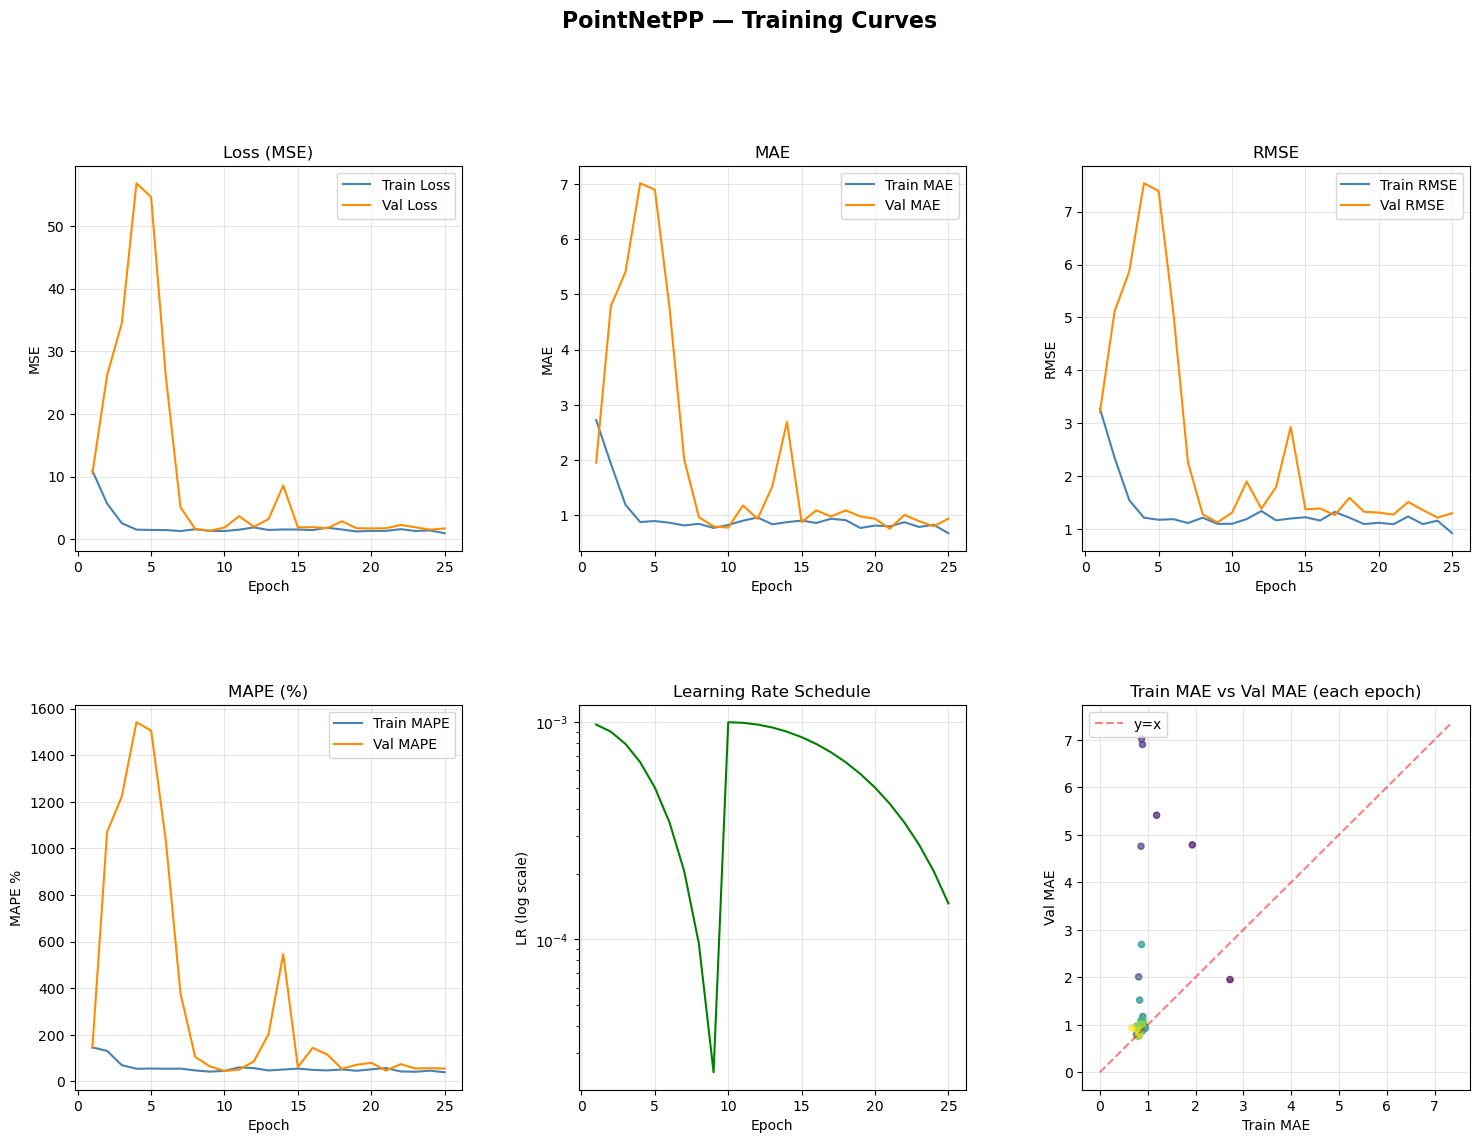

✅ Training curves saved to results/PointNetPP/training_curves.png


In [35]:
def plot_training_curves(history: dict, model_name: str, save_dir: Path) -> None:
    """Plot comprehensive training curves and save."""
    epochs = list(range(1, len(history["train_loss"]) + 1))
    
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"{model_name} — Training Curves", fontsize=16, fontweight='bold', y=1.01)
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)
    
    # 1. Loss (MSE)
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(epochs, history["train_loss"], label="Train Loss", color='steelblue')
    ax.plot(epochs, history["val_loss"],   label="Val Loss",   color='darkorange')
    ax.set_title("Loss (MSE)"); ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
    ax.legend(); ax.grid(alpha=0.3)
    
    # 2. MAE
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(epochs, history["train_mae"], label="Train MAE", color='steelblue')
    ax.plot(epochs, history["val_mae"],   label="Val MAE",   color='darkorange')
    ax.set_title("MAE"); ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
    ax.legend(); ax.grid(alpha=0.3)
    
    # 3. RMSE
    ax = fig.add_subplot(gs[0, 2])
    ax.plot(epochs, history["train_rmse"], label="Train RMSE", color='steelblue')
    ax.plot(epochs, history["val_rmse"],   label="Val RMSE",   color='darkorange')
    ax.set_title("RMSE"); ax.set_xlabel("Epoch"); ax.set_ylabel("RMSE")
    ax.legend(); ax.grid(alpha=0.3)
    
    # 4. MAPE
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(epochs, history["train_mape"], label="Train MAPE", color='steelblue')
    ax.plot(epochs, history["val_mape"],   label="Val MAPE",   color='darkorange')
    ax.set_title("MAPE (%)"); ax.set_xlabel("Epoch"); ax.set_ylabel("MAPE %")
    ax.legend(); ax.grid(alpha=0.3)
    
    # 5. Learning Rate
    ax = fig.add_subplot(gs[1, 1])
    ax.semilogy(epochs, history["lr"], color='green')
    ax.set_title("Learning Rate Schedule"); ax.set_xlabel("Epoch"); ax.set_ylabel("LR (log scale)")
    ax.grid(alpha=0.3)
    
    # 6. Train vs Val MAE scatter
    ax = fig.add_subplot(gs[1, 2])
    ax.scatter(history["train_mae"], history["val_mae"],
               c=epochs, cmap='viridis', alpha=0.7, s=20)
    lim_max = max(max(history["train_mae"]), max(history["val_mae"])) * 1.05
    ax.plot([0, lim_max], [0, lim_max], 'r--', alpha=0.5, label='y=x')
    ax.set_title("Train MAE vs Val MAE (each epoch)")
    ax.set_xlabel("Train MAE"); ax.set_ylabel("Val MAE")
    ax.legend(); ax.grid(alpha=0.3)
    
    plt.tight_layout()
    save_p = save_dir / "training_curves.png"
    plt.savefig(save_p, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"✅ Training curves saved to {save_p}")


plot_training_curves(history, MODEL_NAME, RESULTS_DIR)


---
## 🧪 Section 12: Model Evaluation on Test Set

We load the **best checkpoint** (saved during training) and evaluate on the **held-out test set**.  
The test set was never seen during training — this gives an unbiased estimate of real-world performance.


In [36]:
# ─────────────────────────────────────────────────────────
# Load best checkpoint
# ─────────────────────────────────────────────────────────
print(f"📥 Loading best checkpoint from {SAVE_PATH} ...")

# Re-instantiate model architecture
eval_model = build_model(MODEL_NAME).to(device)

state_dict = torch.load(SAVE_PATH, map_location=device)
eval_model.load_state_dict(state_dict)
eval_model.eval()
print("✅ Checkpoint loaded.")

# ─────────────────────────────────────────────────────────
# Run inference on test set
# ─────────────────────────────────────────────────────────
all_preds   = []
all_targets = []

with torch.no_grad():
    for pts, vols in test_loader:
        pts, vols = pts.to(device), vols.to(device)
        with autocast(enabled=USE_AMP):
            preds = eval_model(pts)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(vols.cpu().numpy())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# ─────────────────────────────────────────────────────────
# Compute metrics
# ─────────────────────────────────────────────────────────
test_metrics = compute_metrics(all_preds, all_targets)

print(f"\n{'='*50}")
print(f"📊  {MODEL_NAME} — Test Set Results")
print(f"{'='*50}")
for metric, val in test_metrics.items():
    print(f"   {metric:<8}: {val:.4f}" + ("%" if metric == "MAPE" else ""))
print(f"{'='*50}")


📥 Loading best checkpoint from results/PointNetPP/best_pointnetpp.pth ...
✅ Checkpoint loaded.

📊  PointNetPP — Test Set Results
   MAE     : 0.8706
   RMSE    : 1.4141
   MSE     : 1.9998
   R2      : 0.7290
   MAPE    : 45.2498%


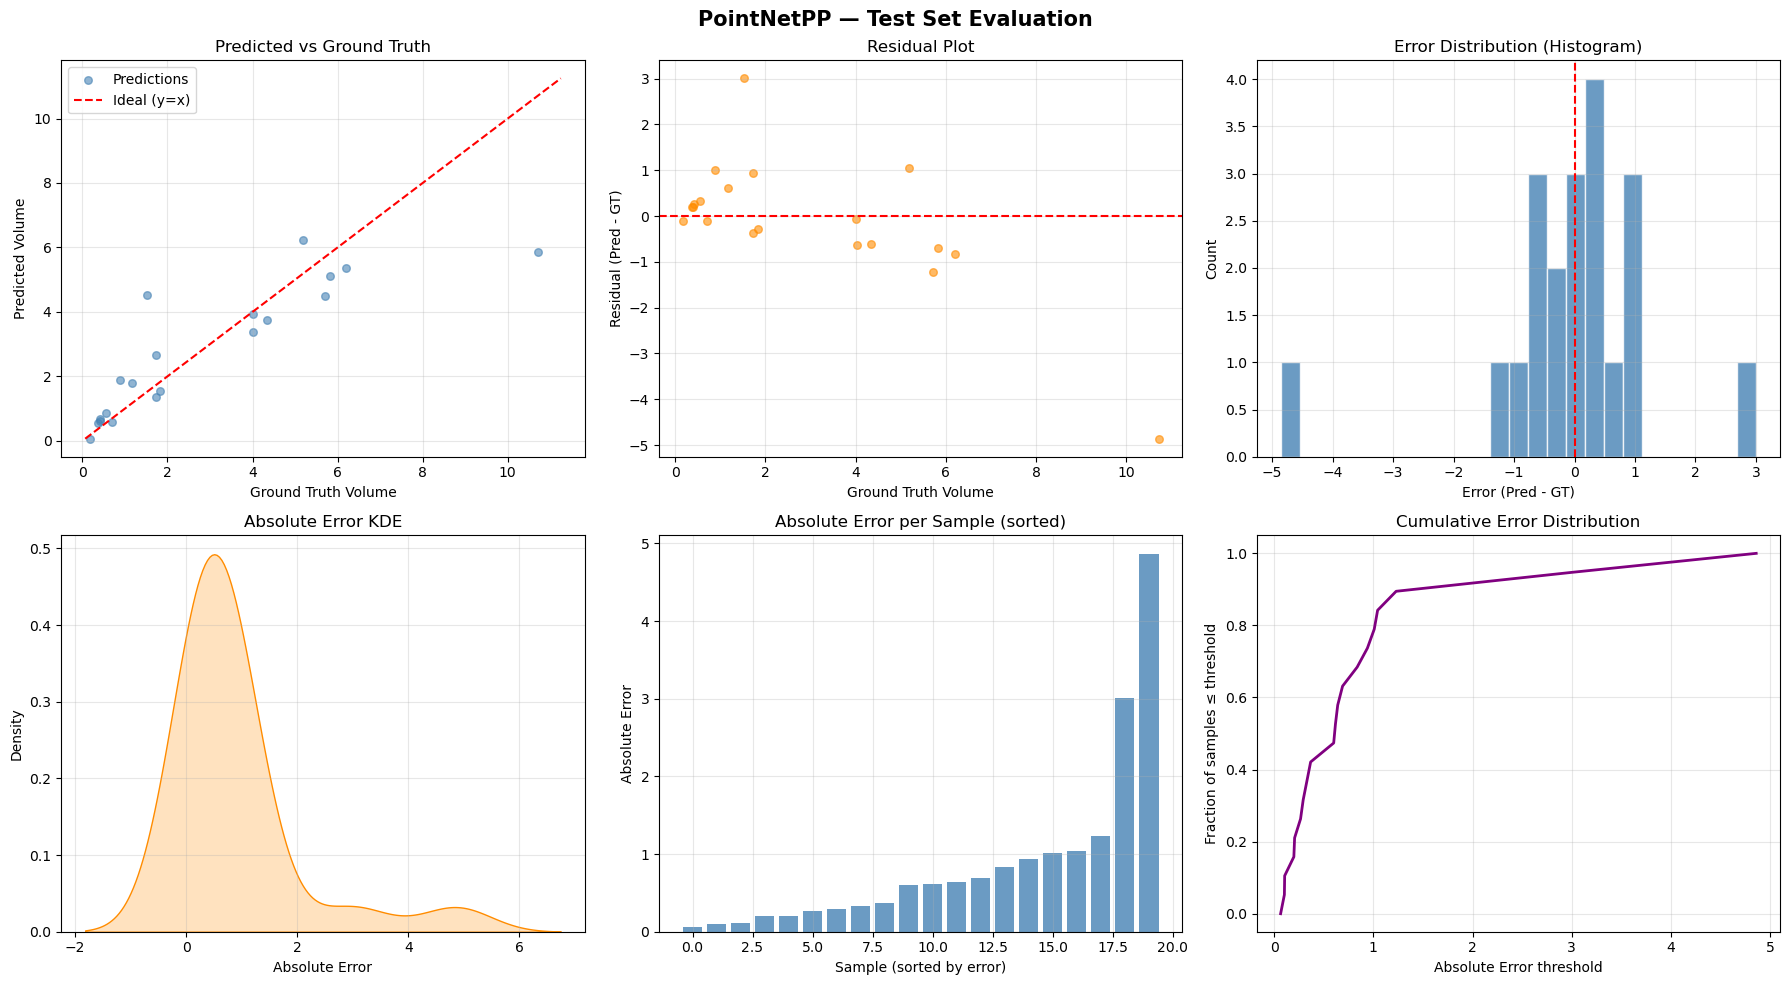

✅ Evaluation plots saved to results/PointNetPP/evaluation_plots.png


In [37]:
# ─────────────────────────────────────────────────────────
# Comprehensive Evaluation Plots
# ─────────────────────────────────────────────────────────

def plot_evaluation(preds, targets, model_name, save_dir):
    """
    Generate 6-panel evaluation figure:
      1. Predicted vs Ground Truth (scatter)
      2. Residuals vs Ground Truth
      3. Error Distribution (histogram)
      4. Error Distribution (KDE)
      5. Absolute Error per sample
      6. Cumulative error distribution
    """
    errors   = preds - targets
    abs_err  = np.abs(errors)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"{model_name} — Test Set Evaluation", fontsize=15, fontweight='bold')
    
    # 1. Pred vs GT scatter
    ax = axes[0, 0]
    lo = min(targets.min(), preds.min()) * 0.95
    hi = max(targets.max(), preds.max()) * 1.05
    ax.scatter(targets, preds, alpha=0.6, s=30, color='steelblue', label='Predictions')
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Ideal (y=x)')
    ax.set_xlabel("Ground Truth Volume"); ax.set_ylabel("Predicted Volume")
    ax.set_title("Predicted vs Ground Truth")
    ax.legend(); ax.grid(alpha=0.3)
    
    # 2. Residual plot
    ax = axes[0, 1]
    ax.scatter(targets, errors, alpha=0.6, s=30, color='darkorange')
    ax.axhline(0, color='red', linestyle='--', lw=1.5)
    ax.set_xlabel("Ground Truth Volume"); ax.set_ylabel("Residual (Pred - GT)")
    ax.set_title("Residual Plot"); ax.grid(alpha=0.3)
    
    # 3. Error histogram
    ax = axes[0, 2]
    ax.hist(errors, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', lw=1.5)
    ax.set_xlabel("Error (Pred - GT)"); ax.set_ylabel("Count")
    ax.set_title("Error Distribution (Histogram)"); ax.grid(alpha=0.3)
    
    # 4. KDE of absolute errors
    ax = axes[1, 0]
    sns.kdeplot(abs_err, ax=ax, fill=True, color='darkorange')
    ax.set_xlabel("Absolute Error"); ax.set_ylabel("Density")
    ax.set_title("Absolute Error KDE"); ax.grid(alpha=0.3)
    
    # 5. Per-sample absolute error (sorted)
    ax = axes[1, 1]
    sorted_err = np.sort(abs_err)
    ax.bar(range(len(sorted_err)), sorted_err, color='steelblue', alpha=0.8)
    ax.set_xlabel("Sample (sorted by error)"); ax.set_ylabel("Absolute Error")
    ax.set_title("Absolute Error per Sample (sorted)"); ax.grid(alpha=0.3)
    
    # 6. Cumulative distribution of absolute error
    ax = axes[1, 2]
    ax.plot(np.sort(abs_err), np.linspace(0, 1, len(abs_err)), color='purple', lw=2)
    ax.set_xlabel("Absolute Error threshold"); ax.set_ylabel("Fraction of samples ≤ threshold")
    ax.set_title("Cumulative Error Distribution"); ax.grid(alpha=0.3)
    
    plt.tight_layout()
    save_p = save_dir / "evaluation_plots.png"
    plt.savefig(save_p, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"✅ Evaluation plots saved to {save_p}")


plot_evaluation(all_preds, all_targets, MODEL_NAME, RESULTS_DIR)


---
## 🔍 Section 13: Inference on a Single File

This section shows how to run inference on a **single new `.las` file** — useful for deployment.


In [38]:
# def predict_volume(las_path: str, model: nn.Module, num_points: int = 2048,
#                    device: torch.device = torch.device('cpu')) -> float:
#     """
#     Predict the volume of a single point cloud file.
    
#     Args:
#         las_path  : path to the .las file
#         model     : trained model (in eval mode)
#         num_points: number of points to sample
#         device    : inference device
    
#     Returns:
#         predicted_volume : float
#     """
#     model.eval()
    
#     # ── Load & preprocess ────────────────────────────────
#     las    = laspy.read(las_path)
#     points = np.vstack((las.x, las.y, las.z)).T.astype(np.float32)
    
#     print(f"   Loaded: {points.shape[0]:,} raw points from {Path(las_path).name}")
    
#     # Sample
#     if len(points) > num_points:
#         # FPS sampling
#         dataset_tmp = WoodPowderDataset.__new__(WoodPowderDataset)
#         points = dataset_tmp.farthest_point_sample(dataset_tmp, points, num_points)
#         # Note: for production, use a standalone FPS function
#     else:
#         idx    = np.random.choice(len(points), num_points, replace=True)
#         points = points[idx]
    
#     # Zero-center
#     points -= np.mean(points, axis=0)
    
#     # Convert to tensor: (1, 3, N) — batch size 1
#     pts_t = torch.from_numpy(points).T.float().unsqueeze(0).to(device)
    
#     # ── Inference ────────────────────────────────────────
#     with torch.no_grad():
#         pred = model(pts_t)
    
#     return pred.item()

def predict_volume(las_path: str, model: nn.Module, num_points: int = 2048,
                   device: torch.device = torch.device('cpu')) -> float:
    model.eval()
    
    las    = laspy.read(las_path)
    points = np.vstack((las.x, las.y, las.z)).T.astype(np.float32)
    print(f"   Loaded: {points.shape[0]:,} raw points from {Path(las_path).name}")
    
    # ── FPS sampling (standalone, no dataset instance needed) ──
    if len(points) > num_points:
        N          = points.shape[0]
        centroids  = np.zeros(num_points, dtype=np.int32)
        distance   = np.ones(N) * 1e10
        farthest   = np.random.randint(0, N)
        for i in range(num_points):
            centroids[i] = farthest
            centroid     = points[farthest, :]
            dist         = np.sum((points - centroid) ** 2, axis=-1)
            mask         = dist < distance
            distance[mask] = dist[mask]
            farthest     = np.argmax(distance)
        points = points[centroids]
    else:
        idx    = np.random.choice(len(points), num_points, replace=True)
        points = points[idx]
    
    points -= np.mean(points, axis=0)
    pts_t   = torch.from_numpy(points).T.float().unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred = model(pts_t)
    return pred.item()
# ─── Example usage ───────────────────────────────────────
# Demonstrate on first test file
first_row  = test_df.iloc[0]
las_fname  = first_row.iloc[0]
true_vol   = first_row.iloc[1]
las_fpath  = str(DATA_DIR / las_fname)

if Path(las_fpath).exists():
    pred_vol = predict_volume(las_fpath, eval_model, NUM_POINTS, device)
    print(f"\n🔍 Single File Inference:")
    print(f"   File            : {las_fname}")
    print(f"   True Volume     : {true_vol:.4f}")
    print(f"   Predicted Volume: {pred_vol:.4f}")
    print(f"   Absolute Error  : {abs(pred_vol - true_vol):.4f}")
    print(f"   MAPE            : {abs(pred_vol - true_vol) / (abs(true_vol) + 1e-8) * 100:.2f}%")
else:
    print(f"⚠️  File not found: {las_fpath}. Skipping single-file inference demo.")


   Loaded: 411,755 raw points from sample_0068.las

🔍 Single File Inference:
   File            : sample_0068.las
   True Volume     : 5.1911
   Predicted Volume: 6.5490
   Absolute Error  : 1.3579
   MAPE            : 26.16%


---
## 🏆 Section 14: Model Comparison & Final Summary

After training each model (by changing `MODEL_NAME` and re-running), all results are appended to `results/model_comparison.csv`.

Here we load that CSV and visualize all models side by side.


In [39]:
# ─────────────────────────────────────────────────────────
# Save this model's results to comparison CSV
# ─────────────────────────────────────────────────────────
new_row = {
    "Model"          : MODEL_NAME,
    "MAE"            : round(test_metrics["MAE"],  4),
    "RMSE"           : round(test_metrics["RMSE"], 4),
    "MSE"            : round(test_metrics["MSE"],  4),
    "R2"             : round(test_metrics["R2"],   4),
    "MAPE_%"         : round(test_metrics["MAPE"], 2),
    "Training_Time_min": round(total_time / 60, 1),
    "Num_Params"     : sum(p.numel() for p in eval_model.parameters()),
    "Best_Val_MAPE_%": round(best_val_mape, 2),
    "Epochs_Run"     : len(history["train_loss"])
}

# Append or create
if COMPARISON_CSV.exists():
    comp_df = pd.read_csv(COMPARISON_CSV)
    # Replace if same model exists
    comp_df = comp_df[comp_df["Model"] != MODEL_NAME]
    comp_df = pd.concat([comp_df, pd.DataFrame([new_row])], ignore_index=True)
else:
    comp_df = pd.DataFrame([new_row])

comp_df = comp_df.sort_values("MAPE_%").reset_index(drop=True)
comp_df.to_csv(COMPARISON_CSV, index=False)

print(f"📊 Model comparison table:")
print(comp_df.to_string(index=False))
print(f"\nSaved to: {COMPARISON_CSV}")


📊 Model comparison table:
     Model    MAE   RMSE    MSE     R2    MAPE_%  Training_Time_min  Num_Params  Best_Val_MAPE_%  Epochs_Run
     DGCNN 0.5463 0.8999 0.8099 0.8903 21.330000              118.1     1799553            15.61          45
  PointNet 0.8788 1.7053 2.9080 0.6059 28.490000              101.2     3470026            41.36          40
 PointNeXt 0.5508 0.7692 0.5917 0.9198 30.469999               72.1     5870529            21.31          37
PointNetPP 0.8706 1.4141 1.9998 0.7290 45.250000               49.5     1465665            44.03          25
  PointMAE 1.7427 2.5814 6.6637 0.0970 61.099998               59.3    11330433            50.80          21

Saved to: results/model_comparison.csv


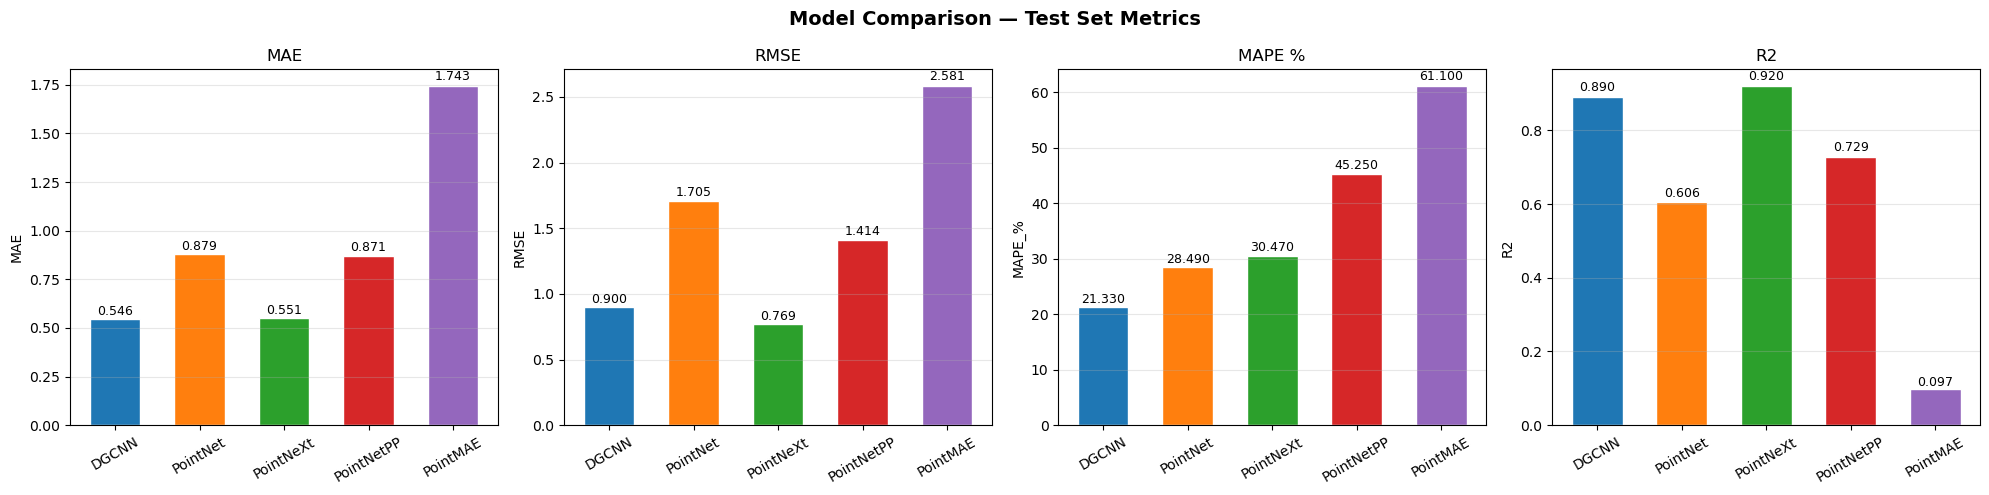

✅ Comparison plot saved.


In [40]:
# ─────────────────────────────────────────────────────────
# Comparison Visualization (if multiple models trained)
# ─────────────────────────────────────────────────────────
if len(comp_df) > 0:
    metrics_to_plot = ["MAE", "RMSE", "MAPE_%", "R2"]
    n_metrics = len(metrics_to_plot)
    
    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5))
    fig.suptitle("Model Comparison — Test Set Metrics", fontsize=14, fontweight='bold')
    
    colors = plt.cm.tab10.colors
    
    for ax, metric in zip(axes, metrics_to_plot):
        vals   = comp_df[metric].values
        models = comp_df["Model"].values
        bars   = ax.bar(models, vals, color=colors[:len(models)], edgecolor='white', width=0.6)
        ax.set_title(metric.replace("_", " "))
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', alpha=0.3)
        # Add value labels on bars
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    f"{v:.3f}", ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "model_comparison.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("✅ Comparison plot saved.")


---
## ✅ Summary

Congratulations! You have successfully:

1. **Explored** the dataset — point counts, volume distribution
2. **Implemented** 5 state-of-the-art point cloud deep learning architectures from scratch with full educational annotations
3. **Trained** with best practices: AMP, gradient clipping, early stopping, cosine LR scheduling
4. **Evaluated** with comprehensive metrics: MAE, RMSE, MSE, R², MAPE
5. **Visualized** training curves, prediction scatter, residuals, and error distributions
6. **Compared** models quantitatively in a unified table

### To train a different model:
```python
MODEL_NAME = "PointNet"   # or "PointNetPP", "PointNeXt", "PointMAE"
```
Then **Kernel → Restart & Run All**.

### Architecture Summary:

| Model | Key Innovation | Complexity | Good For |
|-------|---------------|-----------|----------|
| **PointNet** | Shared MLP + Global MaxPool | Low | Fast baseline, large datasets |
| **PointNet++** | Hierarchical SA layers | Medium | Local+global features |
| **PointNeXt** | InvResMLP blocks | Medium | Better PointNet++ capacity |
| **PointMAE** | Transformer + masked pre-training | High | Transfer learning |
| **DGCNN** | Dynamic graph, EdgeConv | Medium | Rich local structure |
